### Configure API Client

In [10]:
from src.utils.setup import initialise_binance_client

client = initialise_binance_client(testnet=True)

### Load Data

In [11]:
import pandas as pd

In [13]:
df = pd.read_csv("data/raw_ohlcv/BTCUSDT-1h-2017-08-17.csv", index_col='date', parse_dates=['date'])
df = df[["close", "volume"]].copy()

In [14]:
df.head()

,close,volume
date,,
2017-08-17 04:00:00,4308.83,47.181009
2017-08-17 05:00:00,4315.32,23.234916
2017-08-17 06:00:00,4324.35,7.229691
2017-08-17 07:00:00,4349.99,4.443249
2017-08-17 08:00:00,4360.69,0.972807


### Calculating Returns

In [15]:
import numpy as np

In [16]:
df["return"] = df["close"].div(df["close"].shift(1))     # This is the return factor from that period's interval
df["return"] = np.log(df["return"])    # Converts to log returns for additivity and scale
df

,close,volume,return
date,,,
2017-08-17 04:00:00,4308.83,47.181009,NaN
2017-08-17 05:00:00,4315.32,23.234916,0.001505
2017-08-17 06:00:00,4324.35,7.229691,0.002090
2017-08-17 07:00:00,4349.99,4.443249,0.005912
2017-08-17 08:00:00,4360.69,0.972807,0.002457
...,...,...,...
2026-01-28 20:00:00,89130.63,590.946240,-0.003046
2026-01-28 21:00:00,89412.17,381.499940,0.003154
2026-01-28 22:00:00,89396.15,156.235180,-0.000179


### Visualising Data


In [17]:
import matplotlib.pyplot as plt

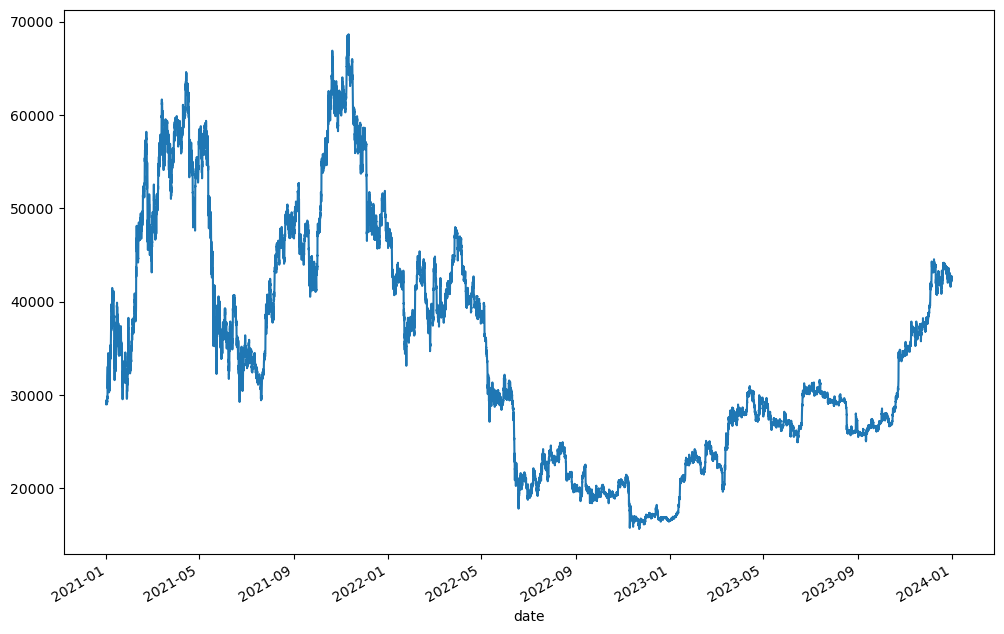

In [18]:
df.close.loc['2021':'2023'].plot(figsize=(12,8))
plt.show()

In [19]:
df

,close,volume,return
date,,,
2017-08-17 04:00:00,4308.83,47.181009,NaN
2017-08-17 05:00:00,4315.32,23.234916,0.001505
2017-08-17 06:00:00,4324.35,7.229691,0.002090
2017-08-17 07:00:00,4349.99,4.443249,0.005912
2017-08-17 08:00:00,4360.69,0.972807,0.002457
...,...,...,...
2026-01-28 20:00:00,89130.63,590.946240,-0.003046
2026-01-28 21:00:00,89412.17,381.499940,0.003154
2026-01-28 22:00:00,89396.15,156.235180,-0.000179


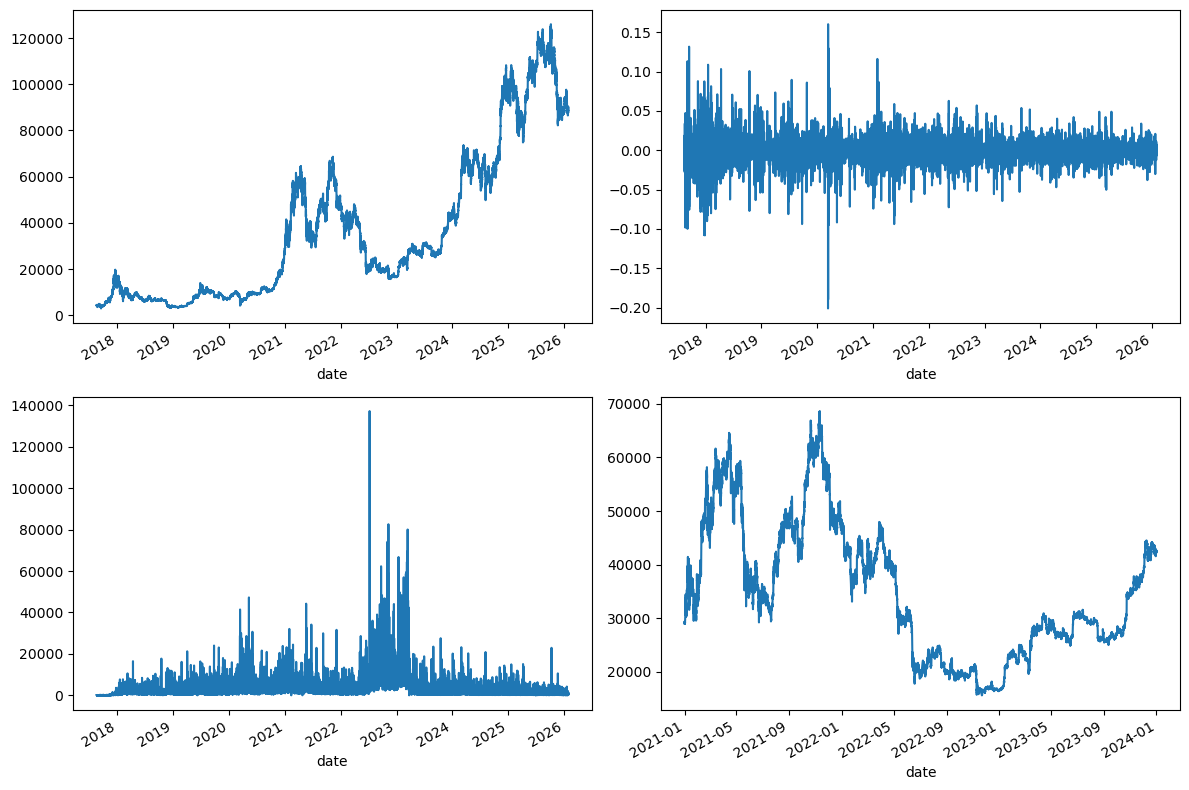

In [20]:
fig, axs = plt.subplots(2,2, figsize=(12,8))

df.close.plot(ax=axs[0,0])
df.volume.plot(ax=axs[1,0])
df.close.loc['2021':'2023'].plot(ax=axs[1,1])
df['return'].plot(ax=axs[0,1])

plt.tight_layout()
plt.show()

### Buy and Hold Strategy

In [21]:
# Normalise Close price with respect to the first price - effectively the multiple at that time
normalised_price_series = df.close / df.close.iloc[0]     

In [22]:
# Calculating the multiple directly
multiple = np.exp(df["return"].sum())
multiple

np.float64(20.676858915297256)

In [23]:
# Cumulative return from buying and holding
df['c_return'] = df['return'].cumsum().apply(np.exp)
df

,close,volume,return,c_return
date,,,,
2017-08-17 04:00:00,4308.83,47.181009,NaN,NaN
2017-08-17 05:00:00,4315.32,23.234916,0.001505,1.001506
2017-08-17 06:00:00,4324.35,7.229691,0.002090,1.003602
2017-08-17 07:00:00,4349.99,4.443249,0.005912,1.009552
2017-08-17 08:00:00,4360.69,0.972807,0.002457,1.012036
...,...,...,...,...
2026-01-28 20:00:00,89130.63,590.946240,-0.003046,20.685576
2026-01-28 21:00:00,89412.17,381.499940,0.003154,20.750916
2026-01-28 22:00:00,89396.15,156.235180,-0.000179,20.747198


### Backtesting Random Strategy

#### Backtester

In [24]:
# Using a subset of data (only 2021) for testing
data = df.loc['2021'].copy()
data['c_return'] = data['return'].cumsum().apply(np.exp)
data

,close,volume,return,c_return
date,,,,
2021-01-01 00:00:00,28995.13,2311.811445,0.002469,1.002472
2021-01-01 01:00:00,29409.99,5403.068471,0.014207,1.016815
2021-01-01 02:00:00,29194.65,2384.231560,-0.007349,1.009370
2021-01-01 03:00:00,29278.40,1461.345077,0.002865,1.012266
2021-01-01 04:00:00,29220.31,2038.046803,-0.001986,1.010257
...,...,...,...,...
2021-12-31 19:00:00,45728.28,3851.309020,-0.020736,1.581001
2021-12-31 20:00:00,45879.24,1831.412020,0.003296,1.586220
2021-12-31 21:00:00,46333.86,1734.695850,0.009860,1.601938


In [25]:
data['position'] = 1

In [26]:
# Random strategy - sells when the close price is mod 10
sell_condition = data['close'] % 10 == 0

In [27]:
data.loc[sell_condition, 'position'] = 0

In [28]:
# Checks to see how many times the strategy is not holding
data.position.value_counts()

position
1    8535
0     212
Name: count, dtype: int64

In [29]:
data['strategy'] = data['position'].shift(1) * data['return']

In [30]:
data['c_strategy'] = data['strategy'].cumsum().apply(np.exp)

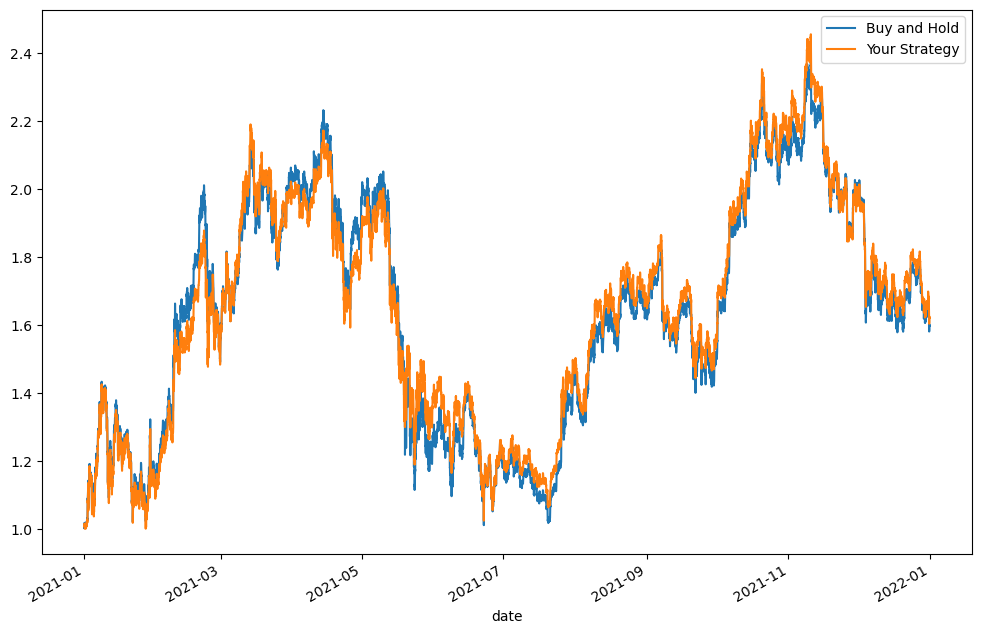

In [31]:
data[['c_return', 'c_strategy']].plot(figsize=(12,8))
plt.legend(['Buy and Hold', 'Your Strategy'])
plt.show()

#### Performance Metrics

In [32]:
# Number of trading periods
trading_periods = 8760

##### Annaulised Mean

In [33]:
ann_mean_log = data[['return', 'strategy']].mean() * trading_periods
ann_mean = np.exp(ann_mean_log) - 1
ann_mean

return      0.599009
strategy    0.622302
dtype: float64

##### Standard Deviation

In [34]:
ann_std = data[['return', 'strategy']].std() * np.sqrt(trading_periods)
ann_std

return      0.861504
strategy    0.847011
dtype: float64

##### Sharpe Ratio

In [35]:
sharpe = (ann_mean / ann_std)
sharpe

return      0.695306
strategy    0.734704
dtype: float64

#### Trading Costs

In [36]:
commission = 0.1 / 100

In [37]:
ptc = np.log(1 - commission)

In [38]:
data['trade'] = data['position'].diff().fillna(0).abs()

In [39]:
data['strategy_net'] = data['strategy'] + data['trade'] * ptc

In [40]:
data['c_strategy_net'] = data['strategy_net'].cumsum().apply(np.exp)

In [41]:
data.c_strategy_net.nlargest(10)

date
2021-03-13 20:00:00    2.030443
2021-03-14 03:00:00    2.020827
2021-03-14 00:00:00    2.017671
2021-03-14 04:00:00    2.016520
2021-03-13 23:00:00    2.015297
2021-03-13 21:00:00    2.014067
2021-03-13 22:00:00    2.012255
2021-03-14 01:00:00    2.011760
2021-03-14 02:00:00    2.011110
2021-03-14 05:00:00    2.009628
Name: c_strategy_net, dtype: float64

In [42]:
data.c_strategy.nlargest(10)

date
2021-11-10 17:00:00    2.456178
2021-11-10 16:00:00    2.452277
2021-11-10 14:00:00    2.447195
2021-11-10 15:00:00    2.445976
2021-11-09 03:00:00    2.442422
2021-11-09 04:00:00    2.442422
2021-11-09 09:00:00    2.441373
2021-11-09 05:00:00    2.436986
2021-11-09 13:00:00    2.436376
2021-11-09 08:00:00    2.435942
Name: c_strategy, dtype: float64

<Axes: xlabel='date'>

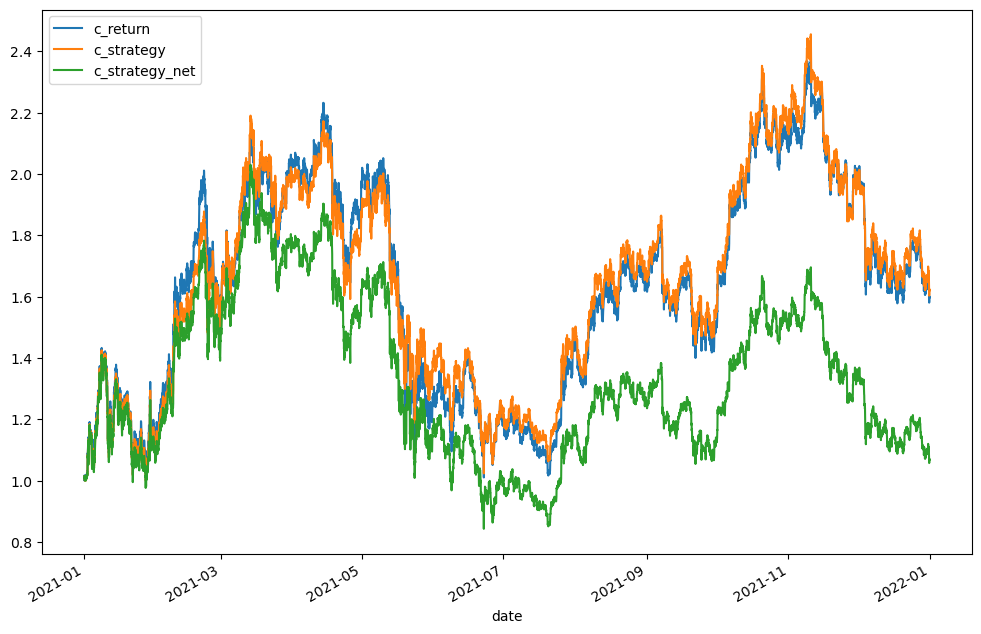

In [43]:
data[['c_return', 'c_strategy', 'c_strategy_net']].plot(figsize=(12,8))